<a href="https://colab.research.google.com/github/AswiniAnnieMathew/MXN441-Assignment2/blob/main/MXN441Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MXN441 Assignment 2**

## **Selected Paper:**

### **Objective:** To assess the accuracy of using simpler ML models with only high-impact predictors compared to the use of all predictors, and to evaluate whether the resulting computational savings and reduced data collection requirements are valuable for practical implementation in various industries.

### Submitted By:

### Aswini Annie Mathew

### Aum Chantapimpa

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **Dataset Overview**

In [6]:
import pandas as pd

# load data
df_backorder_raw = pd.read_csv("https://raw.githubusercontent.com/AswiniAnnieMathew/MXN441-Assignment2/main/Data/Training_Dataset_v2.csv")

In [7]:
# inspect data
df_backorder_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1048575 non-null  int64  
 1   national_inv       1048575 non-null  int64  
 2   lead_time          984057 non-null   float64
 3   in_transit_qty     1048575 non-null  int64  
 4   forecast_3_month   1048575 non-null  int64  
 5   forecast_6_month   1048575 non-null  int64  
 6   forecast_9_month   1048575 non-null  int64  
 7   sales_1_month      1048575 non-null  int64  
 8   sales_3_month      1048575 non-null  int64  
 9   sales_6_month      1048575 non-null  int64  
 10  sales_9_month      1048575 non-null  int64  
 11  min_bank           1048575 non-null  int64  
 12  potential_issue    1048575 non-null  object 
 13  pieces_past_due    1048575 non-null  int64  
 14  perf_6_month_avg   1048575 non-null  float64
 15  perf_12_month_avg  1048575 non-n

The initial inspection shows 23 columns. There are 16 numerical columns and 7 objects. The only column with missing value is lead_time.

### **Variable Description**

Variables can be grouped as below:

| Group | Variables | Description |
|-------|-----------|-------------|
| Identifier | sku | Unique product ID|
| Inventory state | national_inv, lead_time, in_transit_qty | Current stock level, supplier lead time, quantity in transit |
| Forecasted sales | forecast_3_month, forecast_6_month, forecast_9_month | forecasted sales over next 3, 6 and 9 months. |
| Historical sales | sales_1_month, sales_3_month, sales_6_month, sales_9_month | Actual sales over past 1, 3, 6 and 9 months. |
| Stock policy | min_bank | Minimum stock level |
| Supplier performance | perf_6_month_avg, perf_12_month_avg | upplier delivery performance expressed as percentage between 0 and 1 |
| Backlog status | local_bo_qty, pieces_past_due | Local backorder quantity, quanity past the due date from supplier |
| Risk flags | potential_issue, deck_risk, oe_constraint, ppap_risk, stop_auto_buy, rev_stop | Binary Yes or No risk indicators |
| Target | went_on_backorder | Yes or No to indicate if the product went on backorder. |

### **Descriptive Analytics**

**Checking Missing Values**

In [14]:
# checking explicitly for missing values
# Check missing values across all columns
Check_missing_data = df_backorder_raw.isnull().sum()
proportion = (Check_missing_data / len(df_backorder_raw)) * 100
missing_summary = pd.DataFrame({
    'missing_count': Check_missing_data,
    'missing_pct': proportion.round(3)
})
display(missing_summary[missing_summary['missing_count'] > 0])

,missing_count,missing_pct
lead_time,64518,6.153


The column, lead_time is missing values for 6% of total rows.

**Descriptive Summary**

In [56]:
df_backorder_raw.describe().loc[['mean', '50%', 'std', 'min', 'max']]\
                           .rename(index={'50%': 'median'})\
                           .T.round(2)

,mean,median,std,min,max
sku,1773693.32,1810846.00,399577.24,1026827.0,3284914.0
national_inv,489.42,15.00,28595.83,-13491.0,12334404.0
lead_time,7.84,8.00,7.04,0.0,52.0
in_transit_qty,45.36,0.00,1390.54,0.0,489408.0
forecast_3_month,185.23,0.00,5032.30,0.0,1218328.0
forecast_6_month,360.88,0.00,10067.64,0.0,2461360.0
forecast_9_month,528.91,0.00,14895.45,0.0,3777304.0
sales_1_month,57.30,0.00,2067.93,0.0,741774.0
sales_3_month,180.46,1.00,5263.48,0.0,1094112.0
sales_6_month,352.46,2.00,9773.35,0.0,2146625.0


The statistics clearly shows that most of the columns related to sales and forecasts are heavily right skewed which means majority of the products sell in small quantities but a few sell enormously.

**Numerical Variable Analysis**

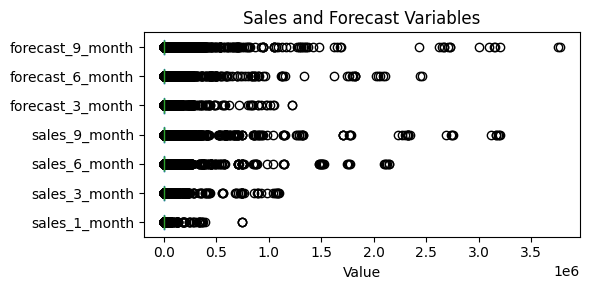

In [47]:
import matplotlib.pyplot as plt
# Group columns by similar scales for readable plots
sales_forecast = ['sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month',
                  'forecast_3_month', 'forecast_6_month', 'forecast_9_month']
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

df_backorder_raw[sales_forecast].plot(kind='box', vert=False, ax=ax)
ax.set_title('Sales and Forecast Variables')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

The current inventory level and performace average shows negative values and understanding these further by looking at the data.

In [22]:

# Display settings
pd.set_option('display.max_rows', 50)
df_backorder_raw[df_backorder_raw['national_inv']< 0]

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
176,1111655,-55,8.0,2,428,526,606,25,100,205,...,0,-99.00,-99.00,56,No,No,No,Yes,No,Yes
191,1111670,-499,12.0,350,3452,5044,7188,747,2550,3572,...,0,0.49,0.72,525,No,No,No,Yes,No,Yes
342,1111821,-48,8.0,97,67,85,115,19,87,165,...,0,0.47,0.47,60,Yes,No,No,Yes,No,No
552,1112031,-1,12.0,0,6,6,6,0,1,2,...,0,0.82,0.79,1,No,No,No,Yes,No,No
916,1112396,-94,9.0,80,5,8,8,205,205,205,...,0,0.91,0.74,0,No,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039749,1398295,-4,NaN,0,0,0,0,0,9,25,...,0,-99.00,-99.00,0,No,No,No,No,No,No
1039835,1398384,-85,12.0,0,126,126,126,0,110,141,...,0,0.00,0.01,0,No,No,No,Yes,No,Yes
1040249,1398825,-6,NaN,0,0,0,0,3,14,49,...,0,-99.00,-99.00,0,No,No,Yes,Yes,No,No
1042276,1400992,-2,NaN,7,0,0,0,4,21,44,...,0,-99.00,-99.00,3,No,No,No,No,No,No


Analysing the relationship between national_inv < 0 and the went_on_backorder column.

In [34]:
# Analyze products with negative national inventory
negative_inventory_rows = df_backorder_raw[df_backorder_raw['national_inv'] < 0]
total_neg_inv_count = negative_inventory_rows.shape[0]

neg_inv_backorder_yes = negative_inventory_rows[negative_inventory_rows['went_on_backorder'] == 'Yes'].shape[0]
neg_inv_backorder_no = negative_inventory_rows[negative_inventory_rows['went_on_backorder'] == 'No'].shape[0]

percentage_neg_inv_backorder_yes = np.round((neg_inv_backorder_yes / total_neg_inv_count * 100), 2)
percentage_neg_inv_backorder_no = np.round((neg_inv_backorder_no / total_neg_inv_count * 100), 2)

print("Negative inventory Level Details\n")
print("Total rows with negative inventory: ",total_neg_inv_count)
print("Went on backorder:", neg_inv_backorder_yes, "(",percentage_neg_inv_backorder_yes, "%)")
print("Did not go on backorder:", neg_inv_backorder_no, "(",percentage_neg_inv_backorder_no, "%)","\n")

pos_inv_backorder_yes = df_backorder_raw[(df_backorder_raw['national_inv'] >= 0) & (df_backorder_raw['went_on_backorder'] == 'Yes')].shape[0]
print("Non-Negative inventory backorders \n")
print("Products with national_inv >= 0 that went on backorder:", pos_inv_backorder_yes,"\n")

total_dataset_rows = df_backorder_raw.shape[0]
total_backorders = neg_inv_backorder_yes + pos_inv_backorder_yes
overall_backorder_rate = np.round((total_backorders / total_dataset_rows * 100), 4)

print("Overall dataset\n")
print("Total rows in dataset:", total_dataset_rows)
print("Total backorders", total_backorders)
print("Overall backorder rate:", overall_backorder_rate)

print("\nComparison of backorder rates\n")
print("Backorder rate for Negative Inventory products:", percentage_neg_inv_backorder_yes,"%")
total_non_neg_inv_rows = total_dataset_rows - total_neg_inv_count
non_neg_inv_backorder_rate = np.round((pos_inv_backorder_yes / total_non_neg_inv_rows * 100), 4)
print("Backorder rate for Non-Negative Inventory products:", non_neg_inv_backorder_rate,"%")


Negative inventory Level Details

Total rows with negative inventory:  3785
Went on backorder: 678 ( 17.91 %)
Did not go on backorder: 3107 ( 82.09 %) 

Non-Negative inventory backorders 

Products with national_inv >= 0 that went on backorder: 8222 

Overall dataset

Total rows in dataset: 1048575
Total backorders 8900
Overall backorder rate: 0.8488

Comparison of backorder rates

Backorder rate for Negative Inventory products: 17.91 %
Backorder rate for Non-Negative Inventory products: 0.787 %


The above analysis shows that Negative Invetory levels are ~22 times more likely to go on backorder. These negative inventory levels analysis shows that most of the at-risk products are fulfilled before going to backorder


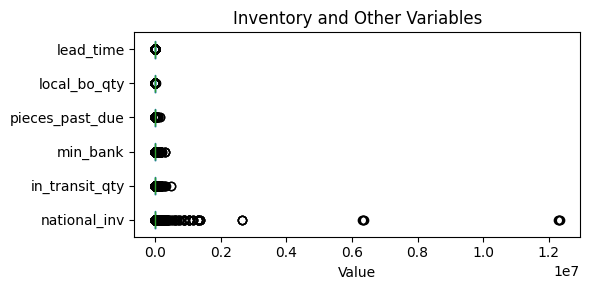

In [48]:
inv = ['national_inv', 'in_transit_qty', 'min_bank',
       'pieces_past_due', 'local_bo_qty', 'lead_time']

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df_backorder_raw[inv].plot(kind='box', vert=False, ax=ax)
ax.set_title('Inventory and Other Variables')
ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

The above box plot also shows some extreme in stock quantities for certain products.

Analysing the negative values in perf_6_month_avg, perf_12_month_avg

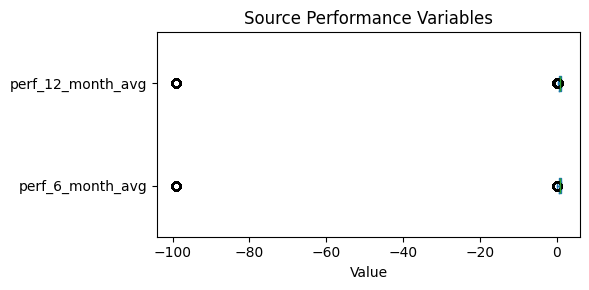

In [53]:
perf = ['perf_6_month_avg', 'perf_12_month_avg']
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df_backorder_raw[perf].plot(kind='box', vert=False, ax=ax)
ax.set_title('Source Performance Variables')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

No rows between 0 and -99 and some rows are exactly -99. Most of values are concentrated between 0 and 1 with a maximum vlaue of 1. This strongly suggests that the isolated -99 value is a code for may be a missing or unkown value and not a measurement. The median is not impacted by extreme outliers and a value of around 0.80 indicates most of the suppliers are reliable.

**Categorical Variable Analysis**

For each risk flag, we analyzed the proportion of flagged items that actually resulted in a backorder state

In [69]:
cat_predictors = ['potential_issue', 'deck_risk', 'oe_constraint',
                  'ppap_risk', 'stop_auto_buy', 'rev_stop']
for col in cat_predictors:
    print("\nAnalysis for: ", col, "\n")
    # Create cross-tab
    ct = pd.crosstab(df_backorder_raw[col], df_backorder_raw['went_on_backorder'], margins=True, margins_name="Total")

    # Calculate percentages for both 'No' and 'Yes' outcomes
    ct_pct = ct.div(ct['Total'], axis=0).multiply(100).round(2)

    # Combine counts and percentages for a clear view
    combined = pd.concat([ct, ct_pct.rename(columns={'No': 'No (%)', 'Yes': 'Yes (%)'})[['No (%)', 'Yes (%)']]], axis=1)

    display(combined[['No', 'No (%)', 'Yes', 'Yes (%)', 'Total']])


Analysis for:  potential_issue 



went_on_backorder,No,No (%),Yes,Yes (%),Total
potential_issue,,,,,
No,1039042,99.15,8861,0.85,1047903
Yes,633,94.20,39,5.80,672
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  deck_risk 



went_on_backorder,No,No (%),Yes,Yes (%),Total
deck_risk,,,,,
No,788209,99.08,7349,0.92,795558
Yes,251466,99.39,1551,0.61,253017
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  oe_constraint 



...

went_on_backorder,No,No (%),Yes,Yes (%),Total
ppap_risk,,,,,
No,913616,99.19,7495,0.81,921111
Yes,126059,98.90,1405,1.10,127464
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  stop_auto_buy 



went_on_backorder,No,No (%),Yes,Yes (%),Total
stop_auto_buy,,,,,
No,36585,99.05,351,0.95,36936
Yes,1003090,99.15,8549,0.85,1011639
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  rev_stop 



went_on_backorder,No,No (%),Yes,Yes (%),Total
rev_stop,,,,,
No,1039217,99.15,8900,0.85,1048117
Yes,458,100.00,0,0.00,458
Total,1039675,99.15,8900,0.85,1048575
